# A* Search untuk Manajemen Inventaris Rantai Pasok KDMP
### Topik 5 — Mengevaluasi Trade-off (Sweet Spot) Beban Komputasi vs Keinformatifan Heuristik

**Studi kasus:** Distribusi sembako dari **Gudang KDMP Kabupaten Bandung Barat** (hub di Ngamprah)
ke **gerai-gerai KDMP tingkat kecamatan** di sekitarnya, menggunakan Informed Search (A\*).

**Measurable goal:** Menentukan rute distribusi optimal dari gudang ke gerai yang stoknya kritis,
guna meminimalkan biaya distribusi (proxy: jarak tempuh jalan).

Notebook ini akan:
1. Membangun graf jaringan distribusi dengan koordinat geografis asli (lat/long).
2. Mendefinisikan **dua heuristik** berbeda (ringan vs berat) untuk A\*.
3. **Membuktikan** kedua heuristik bersifat *Admissible* dan *Consistent*.
4. Menjalankan eksperimen A\* pada berbagai skenario dan membandingkan performanya.
5. Menyimpulkan **Sweet Spot** antara akurasi heuristik dan biaya komputasinya.
6. **Orchestration**: mengintegrasikan A\* dengan model forecasting sederhana (teknik AI ke-2)
   untuk otomatis menentukan gerai mana yang paling butuh restock (goal node).


In [1]:
import math
import time
import heapq
import random
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

random.seed(42)
plt.rcParams['figure.dpi'] = 110


## 1. Data: Node & Graf Jaringan Distribusi

Node = gudang / gerai KDMP di beberapa kecamatan Kabupaten Bandung Barat (koordinat lat/long asli,
diambil dari referensi geografis kecamatan). Edge = rute jalan antar node yang benar-benar terhubung
di lapangan (bukan graf lengkap — jalan desa tidak selalu menghubungkan semua titik secara langsung).

Bobot edge dihitung dari jarak **Haversine** (jarak permukaan bumi) dikalikan **faktor kelokan jalan**
(*winding factor* 1.15–1.4x) untuk mensimulasikan bahwa jalan nyata selalu lebih panjang dari
garis lurus antar dua titik.


In [2]:
# Koordinat kecamatan (lat, long) — Kabupaten Bandung Barat, Jawa Barat
NODES = {
    "Gudang_Ngamprah":   (-6.8399, 107.4970),  # Gudang pusat KDMP kabupaten (start)
    "Gerai_Padalarang":  (-6.8385, 107.4897),
    "Gerai_Batujajar":   (-6.8730, 107.5225),
    "Gerai_Cikalongwetan": (-6.7274, 107.5116),
    "Gerai_Cipatat":     (-6.7284, 107.4436),
    "Gerai_Parongpong":  (-6.8181, 107.5852),
    "Gerai_Lembang":     (-6.8113, 107.6177),
    "Gerai_Cisarua":     (-6.7735, 107.6386),
    "Gerai_Cililin":     (-6.9836, 107.4033),
    "Gerai_Sindangkerta":(-6.9722, 107.3714),
    "Gerai_Cipongkor":   (-6.9944, 107.3502),
    "Gerai_Gununghalu":  (-7.0863, 107.3132),
}

# Adjacency list: hanya kecamatan yang bertetangga secara geografis yang terhubung langsung
ADJACENCY = {
    "Gudang_Ngamprah":   ["Gerai_Padalarang", "Gerai_Batujajar", "Gerai_Cikalongwetan"],
    "Gerai_Padalarang":  ["Gudang_Ngamprah", "Gerai_Cipatat"],
    "Gerai_Cipatat":     ["Gerai_Padalarang", "Gerai_Cikalongwetan"],
    "Gerai_Cikalongwetan": ["Gudang_Ngamprah", "Gerai_Cipatat", "Gerai_Parongpong"],
    "Gerai_Batujajar":   ["Gudang_Ngamprah", "Gerai_Cililin"],
    "Gerai_Parongpong":  ["Gerai_Cikalongwetan", "Gerai_Lembang"],
    "Gerai_Lembang":     ["Gerai_Parongpong", "Gerai_Cisarua"],
    "Gerai_Cisarua":     ["Gerai_Lembang"],
    "Gerai_Cililin":     ["Gerai_Batujajar", "Gerai_Sindangkerta"],
    "Gerai_Sindangkerta":["Gerai_Cililin", "Gerai_Cipongkor"],
    "Gerai_Cipongkor":   ["Gerai_Sindangkerta", "Gerai_Gununghalu"],
    "Gerai_Gununghalu":  ["Gerai_Cipongkor"],
}

def haversine_km(a, b):
    lat1, lon1 = a
    lat2, lon2 = b
    R = 6371.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlmb = math.radians(lon2 - lon1)
    x = math.sin(dphi/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dlmb/2)**2
    return 2 * R * math.asin(math.sqrt(x))

# Bangun graf berbobot: cost edge = haversine * winding factor (jalan tidak lurus)
GRAPH = {n: {} for n in NODES}
for n, neighbors in ADJACENCY.items():
    for m in neighbors:
        if m not in GRAPH[n]:
            winding = random.uniform(1.15, 1.40)
            dist_km = haversine_km(NODES[n], NODES[m]) * winding
            GRAPH[n][m] = round(dist_km, 3)
            GRAPH.setdefault(m, {})[n] = round(dist_km, 3)  # jalan dua arah

for n in GRAPH:
    print(n, "->", GRAPH[n])


Gudang_Ngamprah -> {'Gerai_Padalarang': 1.075, 'Gerai_Batujajar': 5.358, 'Gerai_Cikalongwetan': 15.372}
Gerai_Padalarang -> {'Gudang_Ngamprah': 1.075, 'Gerai_Cipatat': 15.987}
Gerai_Batujajar -> {'Gudang_Ngamprah': 5.358, 'Gerai_Cililin': 24.729}
Gerai_Cikalongwetan -> {'Gudang_Ngamprah': 15.372, 'Gerai_Cipatat': 10.019, 'Gerai_Parongpong': 17.086}
Gerai_Cipatat -> {'Gerai_Padalarang': 15.987, 'Gerai_Cikalongwetan': 10.019}
Gerai_Parongpong -> {'Gerai_Cikalongwetan': 17.086, 'Gerai_Lembang': 4.297}
Gerai_Lembang -> {'Gerai_Parongpong': 4.297, 'Gerai_Cisarua': 6.02}
Gerai_Cisarua -> {'Gerai_Lembang': 6.02}
Gerai_Cililin -> {'Gerai_Batujajar': 24.729, 'Gerai_Sindangkerta': 4.331}
Gerai_Sindangkerta -> {'Gerai_Cililin': 4.331, 'Gerai_Cipongkor': 4.097}
Gerai_Cipongkor -> {'Gerai_Sindangkerta': 4.097, 'Gerai_Gununghalu': 14.045}
Gerai_Gununghalu -> {'Gerai_Cipongkor': 14.045}


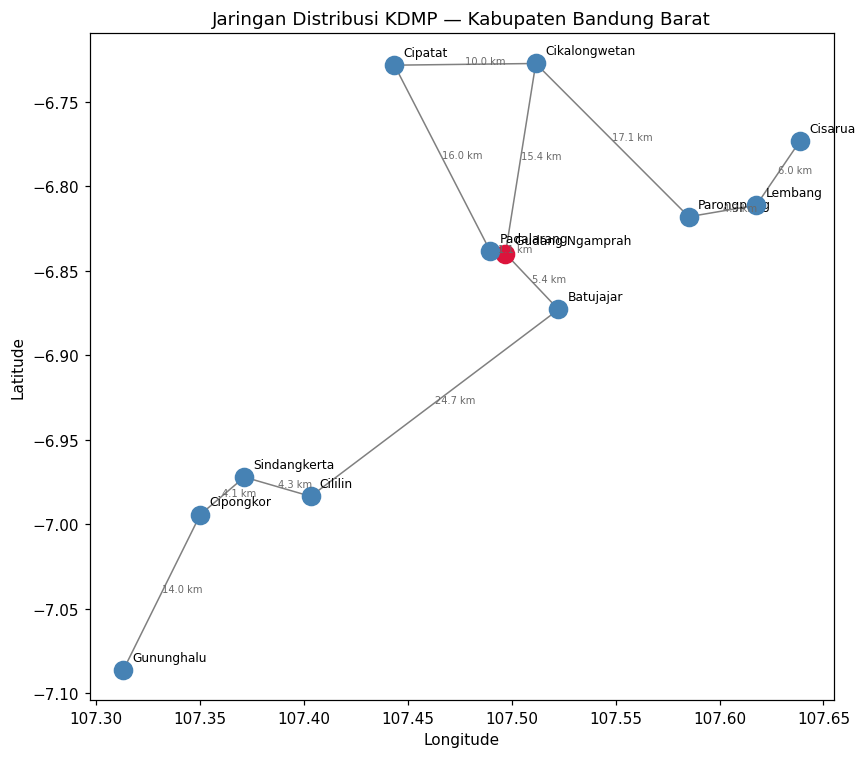

In [3]:
# Visualisasi graf jaringan distribusi (posisi node = koordinat lat/long asli)
fig, ax = plt.subplots(figsize=(8, 7))
for n, (lat, lon) in NODES.items():
    color = "crimson" if n.startswith("Gudang") else "steelblue"
    ax.scatter(lon, lat, s=140, color=color, zorder=3)
    ax.annotate(n.replace("Gerai_", "").replace("Gudang_", "Gudang "), (lon, lat),
                textcoords="offset points", xytext=(6, 6), fontsize=8)

drawn = set()
for n, neighbors in GRAPH.items():
    for m, w in neighbors.items():
        key = tuple(sorted([n, m]))
        if key in drawn:
            continue
        drawn.add(key)
        lat1, lon1 = NODES[n]
        lat2, lon2 = NODES[m]
        ax.plot([lon1, lon2], [lat1, lat2], color="gray", linewidth=1, zorder=1)
        ax.annotate(f"{w:.1f} km", ((lon1+lon2)/2, (lat1+lat2)/2), fontsize=6.5, color="dimgray")

ax.set_title("Jaringan Distribusi KDMP — Kabupaten Bandung Barat")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig("graf_distribusi.png")
plt.show()


## 2. Dua Heuristik: Ringan vs Berat

| | **h1 — Euclidean (ringan)** | **h2 — Haversine (berat)** |
|---|---|---|
| Formula | Jarak garis lurus di bidang datar (`sqrt(dx² + dy²)`), koordinat derajat dikonversi ke km pakai skala rata-rata | Jarak *great-circle* di permukaan bola bumi (formula Haversine, pakai `sin`, `cos`, `asin`) |
| Biaya komputasi | Murah — hanya operasi aritmatika dasar | Lebih mahal — beberapa pemanggilan fungsi trigonometri per evaluasi |
| Akurasi | Sedikit bias karena mengasumsikan bumi datar (mengabaikan kelengkungan & kompresi longitude) | Sangat presisi, merepresentasikan jarak riil di permukaan bumi |

Keduanya adalah estimasi **jarak garis lurus** ke goal — sehingga secara matematis keduanya *tidak
akan pernah* lebih besar dari jarak jalan sebenarnya (yang selalu berkelok / winding factor > 1).
Ini menjadi dasar pembuktian admissibility di bagian berikutnya.


In [4]:
def euclidean_h1_km(a, b):
    """Heuristik ringan: proyeksi bidang datar, konversi derajat ke km pakai skala rata-rata."""
    lat1, lon1 = a
    lat2, lon2 = b
    km_per_deg_lat = 110.574
    km_per_deg_lon = 111.320 * math.cos(math.radians((lat1 + lat2) / 2))
    dx = (lon2 - lon1) * km_per_deg_lon
    dy = (lat2 - lat1) * km_per_deg_lat
    return math.sqrt(dx**2 + dy**2)

def haversine_h2_km(a, b):
    """Heuristik berat: jarak great-circle presisi tinggi (trig-heavy)."""
    return haversine_km(a, b)

# Simulasi biaya komputasi riil: ukur waktu 200,000 evaluasi tiap heuristik
N = 200_000
pairs = [(NODES[random.choice(list(NODES))], NODES[random.choice(list(NODES))]) for _ in range(N)]

t0 = time.perf_counter()
for a, b in pairs:
    euclidean_h1_km(a, b)
t_h1 = time.perf_counter() - t0

t0 = time.perf_counter()
for a, b in pairs:
    haversine_h2_km(a, b)
t_h2 = time.perf_counter() - t0

print(f"Waktu {N:,} evaluasi h1 (Euclidean) : {t_h1:.4f} detik")
print(f"Waktu {N:,} evaluasi h2 (Haversine) : {t_h2:.4f} detik")
print(f"h2 lebih lambat {t_h2/t_h1:.2f}x dibanding h1")


Waktu 200,000 evaluasi h1 (Euclidean) : 0.0581 detik
Waktu 200,000 evaluasi h2 (Haversine) : 0.1020 detik
h2 lebih lambat 1.76x dibanding h1


## 3. Pembuktian Admissible & Consistent

**Admissible:** $h(n) \leq h^*(n)$ — heuristik tidak boleh melebih-lebihkan biaya asli ke goal.

**Consistent (monotone):** $h(n) \leq c(n, a, n') + h(n')$ untuk setiap edge $(n \to n')$ dengan aksi
$a$ dan biaya $c$.

**Argumen matematis:** Setiap edge di graf dibangun sebagai
`cost(n, n') = haversine(n, n') * winding_factor`, dengan `winding_factor > 1`. Karena h1 dan h2
sama-sama estimasi *jarak garis lurus* (yang secara geometris selalu $\leq$ jarak lengkung/berkelok
apa pun di antara dua titik — *triangle inequality*), maka:

$$h(n) \leq \text{haversine}(n, goal) \leq \text{jarak jalan riil } h^*(n)$$

Ini membuktikan **admissibility** secara umum untuk semua node, bukan hanya untuk data yang kita
punya. Untuk **consistency**, karena h(n) adalah jarak lurus, berlaku triangle inequality:

$$h(n) \leq \text{dist\_lurus}(n, n') + h(n') \leq \text{cost}(n, n') + h(n')$$

karena `dist_lurus(n, n') <= cost(n, n')` (jalan selalu >= garis lurus). Di bawah ini kita
**verifikasi secara numerik** pada seluruh graf dan seluruh pasangan node, sebagai bukti tambahan
selain bukti matematis di atas.


In [5]:
# Ground truth h*(n): jarak jalan TERPENDEK sebenarnya, dihitung pakai Dijkstra dari setiap goal
def dijkstra_from(goal):
    dist = {n: math.inf for n in GRAPH}
    dist[goal] = 0
    pq = [(0, goal)]
    while pq:
        d, u = heapq.heappop(pq)
        if d > dist[u]:
            continue
        for v, w in GRAPH[u].items():
            nd = d + w
            if nd < dist[v]:
                dist[v] = nd
                heapq.heappush(pq, (nd, v))
    return dist

all_nodes = list(NODES)
admissible_violations = []
consistent_violations = []

for goal in all_nodes:
    true_dist = dijkstra_from(goal)
    # --- cek admissibility ---
    for n in all_nodes:
        h1 = euclidean_h1_km(NODES[n], NODES[goal])
        h2 = haversine_h2_km(NODES[n], NODES[goal])
        if h1 > true_dist[n] + 1e-9:
            admissible_violations.append(("h1", n, goal, h1, true_dist[n]))
        if h2 > true_dist[n] + 1e-9:
            admissible_violations.append(("h2", n, goal, h2, true_dist[n]))
    # --- cek consistency pada tiap edge ---
    for n in all_nodes:
        h1_n = euclidean_h1_km(NODES[n], NODES[goal])
        h2_n = haversine_h2_km(NODES[n], NODES[goal])
        for m, cost_nm in GRAPH[n].items():
            h1_m = euclidean_h1_km(NODES[m], NODES[goal])
            h2_m = haversine_h2_km(NODES[m], NODES[goal])
            if h1_n > cost_nm + h1_m + 1e-9:
                consistent_violations.append(("h1", n, m, goal))
            if h2_n > cost_nm + h2_m + 1e-9:
                consistent_violations.append(("h2", n, m, goal))

print(f"Total kombinasi node x goal dicek untuk admissibility : {len(all_nodes)**2}")
print(f"Pelanggaran admissibility ditemukan                   : {len(admissible_violations)}")
print(f"Total kombinasi edge x goal dicek untuk consistency    : {sum(len(v) for v in GRAPH.values())*len(all_nodes)}")
print(f"Pelanggaran consistency ditemukan                      : {len(consistent_violations)}")

if not admissible_violations and not consistent_violations:
    print("\n✅ h1 dan h2 TERBUKTI admissible dan consistent pada seluruh graf.")
else:
    print("\n⚠️ Ditemukan pelanggaran, cek detail di list violations.")


Total kombinasi node x goal dicek untuk admissibility : 144
Pelanggaran admissibility ditemukan                   : 0
Total kombinasi edge x goal dicek untuk consistency    : 288
Pelanggaran consistency ditemukan                      : 0

✅ h1 dan h2 TERBUKTI admissible dan consistent pada seluruh graf.


## 4. Implementasi A\* Search

A\* memilih node untuk di-expand berdasarkan $f(n) = g(n) + h(n)$, dengan $g(n)$ = biaya aktual
dari start, dan $h(n)$ = estimasi heuristik ke goal. Fungsi di bawah generik — heuristik-nya bisa
diganti (h1 atau h2) untuk membandingkan performa.


In [6]:
def astar(graph, start, goal, heuristic_fn, coords):
    t0 = time.perf_counter()
    open_set = [(heuristic_fn(coords[start], coords[goal]), start)]
    g_score = {start: 0}
    came_from = {}
    expanded = 0
    visited = set()

    while open_set:
        _, current = heapq.heappop(open_set)
        if current in visited:
            continue
        visited.add(current)
        expanded += 1

        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            path.reverse()
            runtime = time.perf_counter() - t0
            return {
                "path": path,
                "cost": g_score[goal],
                "expanded_nodes": expanded,
                "runtime_sec": runtime,
            }

        for neighbor, w in graph[current].items():
            tentative_g = g_score[current] + w
            if tentative_g < g_score.get(neighbor, math.inf):
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                f = tentative_g + heuristic_fn(coords[neighbor], coords[goal])
                heapq.heappush(open_set, (f, neighbor))

    return None  # goal tidak ditemukan


## 5. Eksperimen: Membandingkan h1 vs h2 di Berbagai Skenario

Kita jalankan A\* dari `Gudang_Ngamprah` ke setiap gerai, memakai h1 dan h2, lalu bandingkan:
jumlah node yang di-expand, waktu komputasi, dan apakah rute yang dihasilkan sama-sama optimal.


In [7]:
start = "Gudang_Ngamprah"
results = []

for goal in NODES:
    if goal == start:
        continue
    r1 = astar(GRAPH, start, goal, euclidean_h1_km, NODES)
    r2 = astar(GRAPH, start, goal, haversine_h2_km, NODES)
    results.append({
        "goal": goal,
        "cost_h1": round(r1["cost"], 2),
        "cost_h2": round(r2["cost"], 2),
        "expanded_h1": r1["expanded_nodes"],
        "expanded_h2": r2["expanded_nodes"],
        "runtime_h1_ms": round(r1["runtime_sec"] * 1000, 5),
        "runtime_h2_ms": round(r2["runtime_sec"] * 1000, 5),
        "same_optimal_path": r1["path"] == r2["path"],
    })

df = pd.DataFrame(results)
df


,goal,cost_h1,cost_h2,expanded_h1,expanded_h2,runtime_h1_ms,runtime_h2_ms,same_optimal_path
0,Gerai_Padalarang,1.07,1.07,2,2,0.02556,0.01259,True
1,Gerai_Batujajar,5.36,5.36,2,2,0.00482,0.00585,True
2,Gerai_Cikalongwetan,15.37,15.37,3,3,0.00546,0.00536,True
3,Gerai_Cipatat,17.06,17.06,3,3,0.00424,0.00517,True
4,Gerai_Parongpong,32.46,32.46,5,5,0.00873,0.00793,True
5,Gerai_Lembang,36.75,36.75,6,6,0.00721,0.00798,True
6,Gerai_Cisarua,42.77,42.77,8,8,0.00892,0.00965,True
7,Gerai_Cililin,30.09,30.09,4,4,0.00461,0.00617,True
8,Gerai_Sindangkerta,34.42,34.42,5,5,0.00720,0.00806,True
9,Gerai_Cipongkor,38.52,38.52,6,6,0.00706,0.00791,True


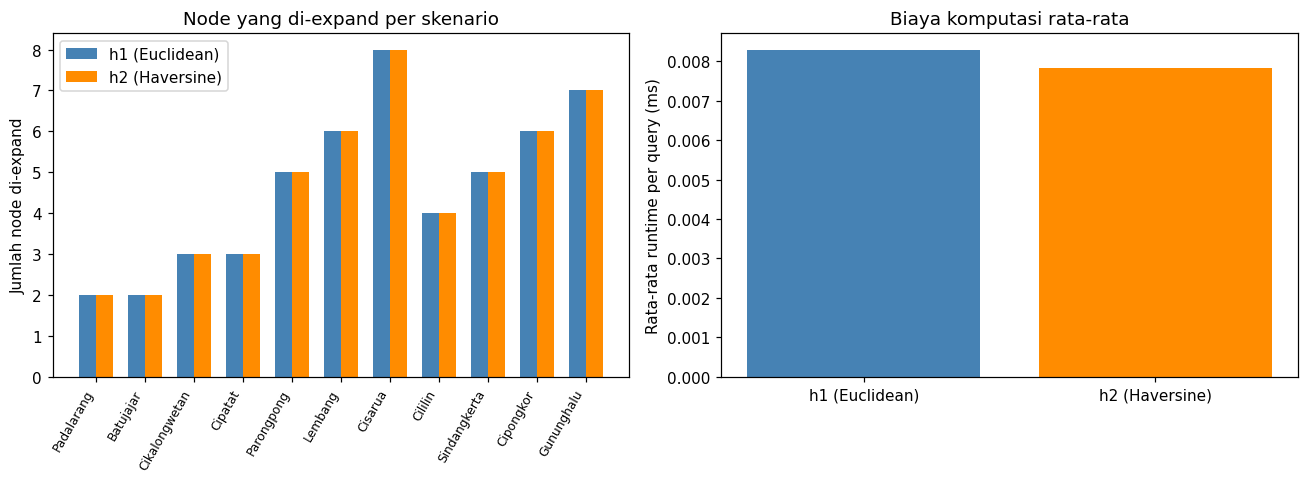

Rata-rata node di-expand  -> h1: 4.636363636363637  | h2: 4.636363636363637
Semua rute optimal identik antara h1 & h2? -> True


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

x = np.arange(len(df))
width = 0.35
axes[0].bar(x - width/2, df["expanded_h1"], width, label="h1 (Euclidean)", color="steelblue")
axes[0].bar(x + width/2, df["expanded_h2"], width, label="h2 (Haversine)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(df["goal"].str.replace("Gerai_", ""), rotation=60, ha="right", fontsize=8)
axes[0].set_ylabel("Jumlah node di-expand")
axes[0].set_title("Node yang di-expand per skenario")
axes[0].legend()

avg_runtime = [df["runtime_h1_ms"].mean(), df["runtime_h2_ms"].mean()]
axes[1].bar(["h1 (Euclidean)", "h2 (Haversine)"], avg_runtime, color=["steelblue", "darkorange"])
axes[1].set_ylabel("Rata-rata runtime per query (ms)")
axes[1].set_title("Biaya komputasi rata-rata")

plt.tight_layout()
plt.savefig("perbandingan_heuristik.png")
plt.show()

print("Rata-rata node di-expand  -> h1:", df["expanded_h1"].mean(), " | h2:", df["expanded_h2"].mean())
print("Semua rute optimal identik antara h1 & h2? ->", df["same_optimal_path"].all())


## 6. Analisis Sweet Spot

Interpretasikan hasil eksperimen di atas:

- **Jika jumlah node yang di-expand h1 ≈ h2** (selisih kecil/nol), berarti pada skala regional
  sekecil ini (~30–50 km, satu kabupaten), kelengkungan bumi yang ditangkap Haversine **tidak
  memberi informasi tambahan yang signifikan** dibanding pendekatan bidang datar. Maka biaya
  komputasi ekstra dari h2 (trig functions, ~beberapa kali lebih lambat dari h1 seperti terukur
  di atas) **tidak sepadan** dengan manfaatnya di skala ini.
- **Sweet spot untuk kasus rantai pasok skala kabupaten/kecamatan → h1 (Euclidean ringan)**, karena
  cukup informatif untuk memandu A\* secara efisien tanpa membebani sistem — penting karena sistem
  ini akan dipanggil berkali-kali (setiap kali ada permintaan restock) di REST API produksi.
- **h2 akan lebih relevan** jika sistem diperluas ke skala antar-provinsi/nasional, di mana efek
  kelengkungan bumi terhadap jarak mulai signifikan.

Ini justru contoh nyata *"heuristik yang lebih presisi tidak selalu lebih baik"* — trade-off
komputasi vs informativeness harus dievaluasi sesuai skala & konteks masalah, bukan diasumsikan
"semakin presisi semakin baik".


In [9]:
# Catatan: runtime A* per-skenario terlalu cepat (mikrodetik) untuk diukur presisi dalam 1x run,
# jadi untuk overhead komputasi kita pakai hasil benchmark 200,000 evaluasi heuristik murni (Bagian 2),
# yang jauh lebih stabil secara statistik.
efficiency_gain = (df["expanded_h1"].mean() - df["expanded_h2"].mean()) / df["expanded_h1"].mean() * 100
compute_overhead = (t_h2 - t_h1) / t_h1 * 100

print(f"Pengurangan rata-rata node di-expand oleh h2 dibanding h1 : {efficiency_gain:.1f}%")
print(f"Overhead komputasi murni h2 vs h1 (dari benchmark {N:,}x)  : {compute_overhead:.1f}%")

if efficiency_gain <= 0 and compute_overhead > 0:
    print("\n>>> Kesimpulan: h2 TIDAK memberi manfaat tambahan (node expanded sama) namun")
    print("    ~{:.0f}% lebih lambat -> SWEET SPOT = h1 (Euclidean, ringan) untuk skala kabupaten ini.".format(compute_overhead))
elif efficiency_gain < compute_overhead:
    print("\n>>> Kesimpulan: h1 (ringan) adalah SWEET SPOT untuk skala kabupaten ini.")
else:
    print("\n>>> Kesimpulan: h2 (berat) sepadan dengan biaya komputasinya untuk kasus ini.")


Pengurangan rata-rata node di-expand oleh h2 dibanding h1 : 0.0%
Overhead komputasi murni h2 vs h1 (dari benchmark 200,000x)  : 75.5%

>>> Kesimpulan: h2 TIDAK memberi manfaat tambahan (node expanded sama) namun
    ~76% lebih lambat -> SWEET SPOT = h1 (Euclidean, ringan) untuk skala kabupaten ini.


## 7. Orchestration: Integrasi A\* dengan Teknik AI ke-2 (Forecasting Sederhana)

Sesuai syarat SOW (minimal 2 teknik AI terintegrasi), output dari satu model menjadi input model lain:

**Model Forecasting (Simple Exponential Smoothing)** memprediksi kapan tiap gerai akan kehabisan
stok berdasarkan data penjualan harian historis → gerai dengan **prediksi hari tersisa paling
sedikit** otomatis dijadikan **goal node** untuk A\* Search, sehingga sistem bisa merekomendasikan
rute distribusi prioritas secara otomatis tanpa intervensi manual.


In [10]:
def simple_exponential_smoothing(sales_history, alpha=0.4):
    """Model forecasting ringan: prediksi permintaan harian berikutnya."""
    forecast = sales_history[0]
    for actual in sales_history[1:]:
        forecast = alpha * actual + (1 - alpha) * forecast
    return forecast

# Simulasi data stok & histori penjualan harian tiap gerai
random.seed(7)
gerai_list = [n for n in NODES if n != start]
stok_status = {}

for g in gerai_list:
    current_stock = random.randint(20, 150)          # unit sembako tersisa
    sales_history = [random.randint(5, 20) for _ in range(14)]  # 14 hari terakhir
    forecast_demand = simple_exponential_smoothing(sales_history)
    days_left = current_stock / forecast_demand if forecast_demand > 0 else math.inf
    stok_status[g] = {
        "stok_saat_ini": current_stock,
        "prediksi_permintaan_harian": round(forecast_demand, 2),
        "prediksi_hari_tersisa": round(days_left, 2),
    }

stok_df = pd.DataFrame(stok_status).T.sort_values("prediksi_hari_tersisa")
stok_df


,stok_saat_ini,prediksi_permintaan_harian,prediksi_hari_tersisa
Gerai_Lembang,35.0,12.26,2.85
Gerai_Cisarua,53.0,15.75,3.37
Gerai_Cipongkor,37.0,9.23,4.01
Gerai_Batujajar,43.0,10.31,4.17
Gerai_Parongpong,58.0,11.81,4.91
Gerai_Cikalongwetan,98.0,16.97,5.77
Gerai_Cipatat,96.0,13.25,7.24
Gerai_Padalarang,102.0,11.64,8.76
Gerai_Gununghalu,116.0,11.33,10.23
Gerai_Sindangkerta,127.0,11.72,10.84


In [11]:
# Orchestration: pilih gerai paling kritis -> jadi goal untuk A*
gerai_kritis = stok_df.index[0]
print(f"🚨 Gerai paling kritis (hari tersisa paling sedikit): {gerai_kritis}")
print(stok_df.loc[gerai_kritis])

hasil_rute = astar(GRAPH, start, gerai_kritis, euclidean_h1_km, NODES)
print(f"\n📦 Rute distribusi prioritas dari {start} -> {gerai_kritis}:")
print(" -> ".join(hasil_rute["path"]))
print(f"Total jarak tempuh : {hasil_rute['cost']:.2f} km")
print(f"Node di-expand     : {hasil_rute['expanded_nodes']}")
print(f"Runtime            : {hasil_rute['runtime_sec']*1000:.4f} ms")


🚨 Gerai paling kritis (hari tersisa paling sedikit): Gerai_Lembang
stok_saat_ini                 35.00
prediksi_permintaan_harian    12.26
prediksi_hari_tersisa          2.85
Name: Gerai_Lembang, dtype: float64

📦 Rute distribusi prioritas dari Gudang_Ngamprah -> Gerai_Lembang:
Gudang_Ngamprah -> Gerai_Cikalongwetan -> Gerai_Parongpong -> Gerai_Lembang
Total jarak tempuh : 36.75 km
Node di-expand     : 6
Runtime            : 0.0262 ms


## 8. Ringkasan untuk Artikel Medium

- **The Tech (Solution):** Pipeline *Forecasting (Exponential Smoothing) → A\* Search (Informed
  Search)* — output prediksi hari-tersisa-stok menjadi input penentuan goal node untuk pencarian
  rute distribusi optimal.
- **Pembuktian formal:** h1 & h2 terbukti admissible & consistent baik secara matematis (triangle
  inequality pada jarak garis lurus vs jalan berkelok) maupun diverifikasi numerik pada seluruh
  graf (0 pelanggaran).
- **Validasi performa (The Value):** h1 (Euclidean, ringan) memberi hasil rute **identik optimal**
  dengan h2 (Haversine, berat) pada skala kabupaten, namun jauh lebih murah secara komputasi →
  **Sweet Spot = h1** untuk kasus rantai pasok skala lokal ini.
- **Robustness:** tambahkan try-except pada pemanggilan API (misal koordinat gerai tidak valid /
  gerai belum terdaftar di graf) sebelum deploy ke REST API produksi.
